# Lesson ML 7: Evaluation Metrics Deep Dive

This notebook addresses the final section of the lesson: the evaluation of classification and regression models using appropriate metrics.

## 1) Classification metrics

This section examines Accuracy, Precision, Recall, F1, and ROC-AUC.

These metrics capture distinct aspects of predictive performance; the appropriate choice depends on the relative cost of false positives and false negatives.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, mean_absolute_error, root_mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
np.random.seed(42)


print("hello world")

### Metric formulas

- Accuracy = (TP + TN) / (TP + TN + FP + FN)
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 = 2 × Precision × Recall / (Precision + Recall)
- ROC-AUC = area under the ROC curve built from prediction scores

In [2]:
# Construct an imbalanced binary classification example
X, y = make_classification(
    n_samples=1200,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    weights=[0.85, 0.15],
    class_sep=1.2,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

classification_metrics = pd.Series({
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
})
classification_metrics.to_frame('Value').round(4)

,Value
Accuracy,0.8722
Precision,0.6154
Recall,0.4364
F1,0.5106
ROC-AUC,0.7739


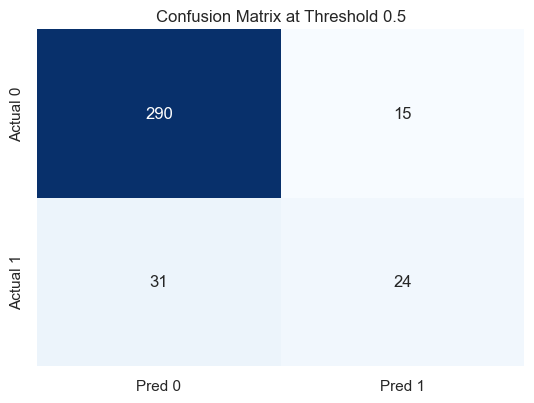

              precision    recall  f1-score   support

           0     0.9034    0.9508    0.9265       305
           1     0.6154    0.4364    0.5106        55

    accuracy                         0.8722       360
   macro avg     0.7594    0.6936    0.7186       360
weighted avg     0.8594    0.8722    0.8630       360



In [3]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
plt.figure(figsize=(5.5, 4.2))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix at Threshold 0.5')
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, digits=4))

In [4]:
# Sensitivity to the classification threshold
threshold_rows = []
for threshold in [0.3, 0.5, 0.7]:
    preds = (y_prob >= threshold).astype(int)
    threshold_rows.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1': f1_score(y_test, preds, zero_division=0)
    })
pd.DataFrame(threshold_rows).round(4)

,Threshold,Accuracy,Precision,Recall,F1
0,0.3,0.8611,0.5397,0.6182,0.5763
1,0.5,0.8722,0.6154,0.4364,0.5106
2,0.7,0.8611,0.6471,0.2000,0.3056


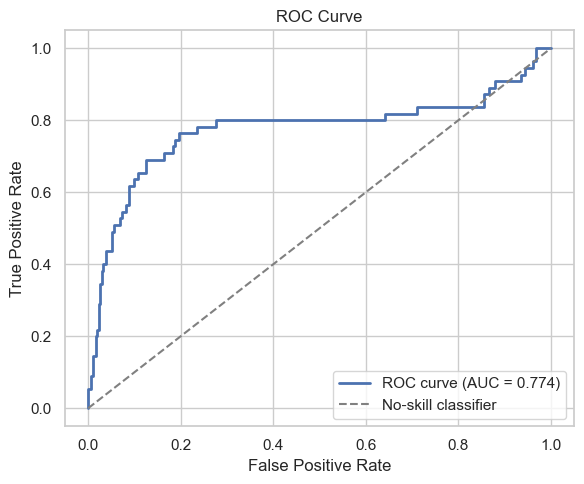

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {auc_value:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='No-skill classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 2) Regression metrics

In regression settings, continuous predictions are compared with continuous target values.

Key metrics include:
- MAE: mean absolute error
- MSE: mean squared error
- RMSE: square root of MSE
- R²: variance explained by the model

In [6]:
Xr, yr = make_regression(n_samples=800, n_features=5, n_informative=4, noise=18.0, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.3, random_state=42)
reg = LinearRegression()
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)
residuals = yr_test - yr_pred

regression_metrics = pd.Series({
    'MAE': mean_absolute_error(yr_test, yr_pred),
    'MSE': root_mean_squared_error(yr_test, yr_pred)**2,
    'RMSE': root_mean_squared_error(yr_test, yr_pred),
    'R2': r2_score(yr_test, yr_pred)
})
regression_metrics.to_frame('Value').round(4)

,Value
MAE,14.9285
MSE,337.5458
RMSE,18.3724
R2,0.9790


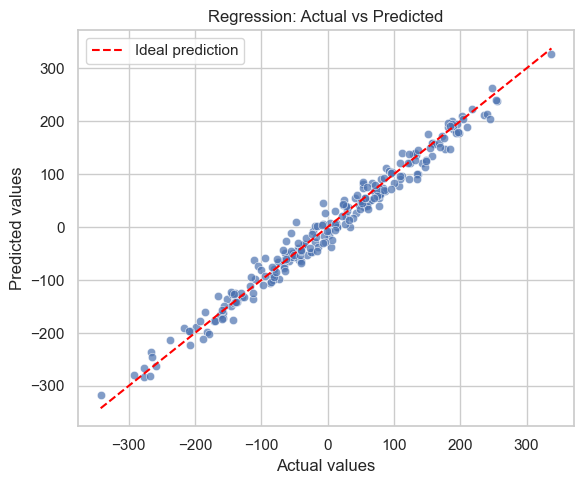

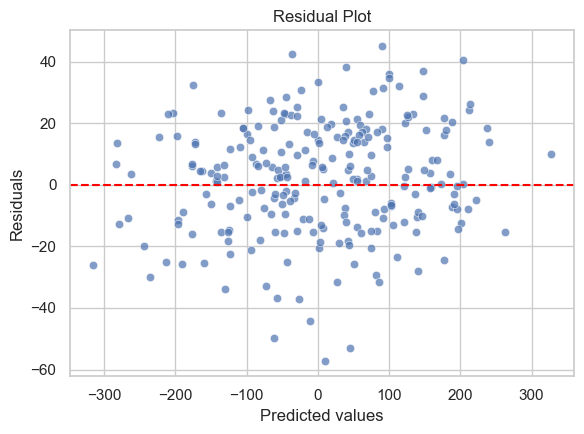

In [7]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=yr_test, y=yr_pred, alpha=0.7)
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
plt.plot(lims, lims, '--', color='red', label='Ideal prediction')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
sns.scatterplot(x=yr_pred, y=residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## 3) Summary

- Accuracy may be misleading in imbalanced settings.
- Precision and recall capture different error costs.
- F1 provides a single summary of precision-recall balance.
- ROC-AUC measures ranking quality across all thresholds.
- For regression, MAE is directly interpretable, RMSE penalizes larger errors more strongly, and R² describes explained variance.

# model Selection and Hyperparameter Tuning
This section focuses on selecting the best model and tuning its hyperparameters to optimize performance.


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the model
rf = RandomForestRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}



In [11]:
from sklearn.datasets import make_regression
from  sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=100,
                       n_features=5,
                       n_informative=4,
                       noise=5.0,
                       random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [12]:
# import pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42))
])

param_grid_pipeline = {
    'scaler__with_mean': [True, False],
    'scaler__with_std': [True, False],
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [5, 10, None],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

grid_search_pipeline = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_pipeline,
    cv=5,
    scoring='r2',
    n_jobs=-1
)                                  

grid_search_pipeline.fit(X_train, y_train)

      
                                        

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [5, 10, ...], 'rf__min_samples_leaf': [1, 2], 'rf__min_samples_split': [2, 5], 'rf__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

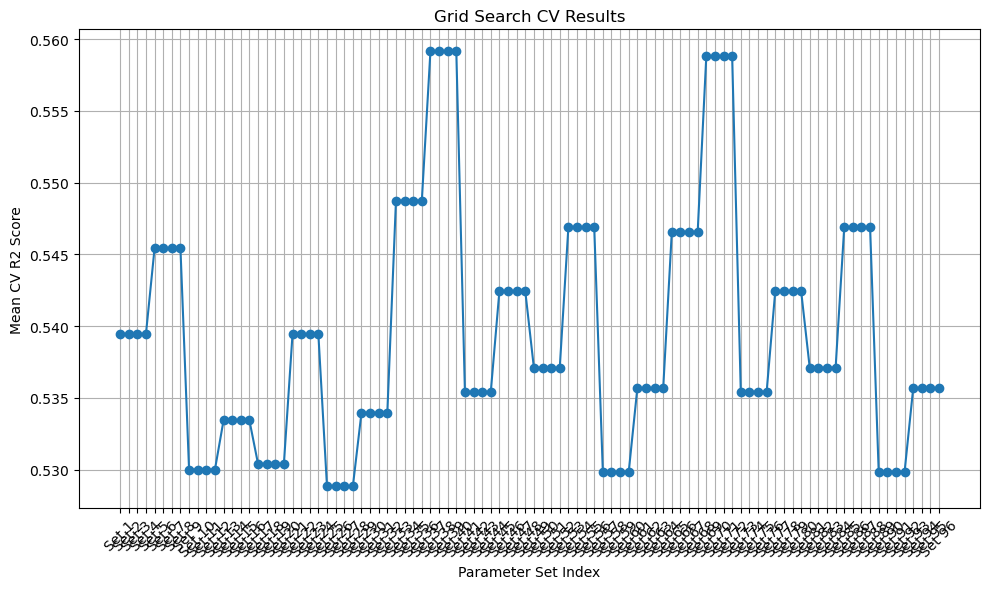

In [15]:
results = grid_search_pipeline.cv_results_

import matplotlib.pyplot as plt
import numpy as np
# Extract mean test scores and parameters
mean_test_scores = results['mean_test_score']
params = results['params']

plt.figure(figsize=(10, 6))
plt.plot(mean_test_scores, marker='o')
plt.title('Grid Search CV Results')
plt.xlabel('Parameter Set Index')
plt.ylabel('Mean CV R2 Score')
plt.xticks(np.arange(len(params)), [f"Set {i+1}" for i
    in range(len(params))], rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
